<a href="https://colab.research.google.com/github/DavidAromose/smartphone-tick-identification/blob/main/pytouch_rare_species_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Confirm GPU is active
import torch
print("GPU available:", torch.cuda.is_available())
print("GPU type:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none")

# Mount Google Drive so images persist across sessions
from google.colab import drive
drive.mount('/content/drive')

# Create a project folder structure on Drive
import os
BASE = '/content/drive/MyDrive/tick_project'
for species_folder in ['ixodes_ricinus', 'ixodes_hexagonus', 'dermacentor_reticulatus',
                        'haemaphysalis_punctata', 'rhipicephalus_sanguineus', 'hyalomma_marginatum']:
    os.makedirs(os.path.join(BASE, 'images', species_folder), exist_ok=True)
print("\nProject folders created under:", BASE)
print("Folders:", os.listdir(os.path.join(BASE, 'images')))

GPU available: True
GPU type: Tesla T4
Mounted at /content/drive

Project folders created under: /content/drive/MyDrive/tick_project
Folders: ['ixodes_ricinus', 'ixodes_hexagonus', 'dermacentor_reticulatus', 'haemaphysalis_punctata', 'rhipicephalus_sanguineus', 'hyalomma_marginatum']


In [ ]:
import requests, time, os
from urllib.parse import urlparse

BASE = '/content/drive/MyDrive/tick_project'

# --- Step 1: query the iNaturalist API for observations ---
# We use taxon NAME here for the test. Later we'll switch to taxon IDs, which are more precise.
params = {
    'taxon_name': 'Ixodes ricinus',
    'quality_grade': 'research',      # community-verified identifications only
    'photos': 'true',                 # must have at least one photo
    'per_page': 30,                   # small test batch
    'page': 1,
    # rough bounding box around Europe (SW corner to NE corner)
    'nelat': 71, 'nelng': 40, 'swlat': 35, 'swlng': -11,
}

r = requests.get('https://api.inaturalist.org/v1/observations', params=params, timeout=30)
print("HTTP status:", r.status_code)

data = r.json()
print("Total matching observations available:", data.get('total_results'))
print("Returned in this page:", len(data.get('results', [])))

# --- Step 2: inspect ONE record so we understand the structure ---
if data.get('results'):
    first = data['results'][0]
    print("\n--- sample record ---")
    print("Species:", first['taxon']['name'])
    print("Observed on:", first.get('observed_on'))
    print("Licence:", first.get('license_code'))
    print("Number of photos:", len(first.get('photos', [])))
    print("Photo URL (square thumb):", first['photos'][0]['url'])

HTTP status: 200
Total matching observations available: 4682
Returned in this page: 30

--- sample record ---
Species: Ixodes ricinus
Observed on: 2026-07-15
Licence: cc-by-sa
Number of photos: 2
Photo URL (square thumb): https://inaturalist-open-data.s3.amazonaws.com/photos/698293250/square.jpg


In [ ]:
import requests, time

species_list = [
    'Ixodes ricinus',
    'Ixodes hexagonus',
    'Dermacentor reticulatus',
    'Haemaphysalis punctata',
    'Rhipicephalus sanguineus',
    'Hyalomma marginatum',
]

EUROPE_BBOX = {'nelat': 71, 'nelng': 40, 'swlat': 35, 'swlng': -11}

print(f"{'Species':<28} {'Research-grade obs (Europe)':>28}")
print("-" * 58)

counts = {}
for sp in species_list:
    params = {
        'taxon_name': sp,
        'quality_grade': 'research',
        'photos': 'true',
        'per_page': 1,          # we only want the count, not the records
        **EUROPE_BBOX,
    }
    r = requests.get('https://api.inaturalist.org/v1/observations',
                     params=params, timeout=30)
    n = r.json().get('total_results', 0)
    counts[sp] = n
    print(f"{sp:<28} {n:>28,}")
    time.sleep(1.2)   # be a good API citizen — ~1 request/sec

print("-" * 58)
print(f"{'TOTAL':<28} {sum(counts.values()):>28,}")

Species                       Research-grade obs (Europe)
----------------------------------------------------------
Ixodes ricinus                                      4,682
Ixodes hexagonus                                       70
Dermacentor reticulatus                             1,958
Haemaphysalis punctata                                 29
Rhipicephalus sanguineus                              207
Hyalomma marginatum                                   285
----------------------------------------------------------
TOTAL                                               7,231


In [ ]:
import requests, time

# Count ACTUAL PHOTOS, not just observations, for the two thin species
thin_species = ['Ixodes hexagonus', 'Haemaphysalis punctata',
                'Rhipicephalus sanguineus', 'Hyalomma marginatum']

EUROPE_BBOX = {'nelat': 71, 'nelng': 40, 'swlat': 35, 'swlng': -11}

print(f"{'Species':<26} {'Obs':>6} {'Photos':>8} {'Photos/obs':>11}")
print("-" * 55)

for sp in thin_species:
    total_photos = 0
    total_obs = 0
    page = 1
    while True:
        params = {
            'taxon_name': sp, 'quality_grade': 'research', 'photos': 'true',
            'per_page': 200, 'page': page, **EUROPE_BBOX,
        }
        r = requests.get('https://api.inaturalist.org/v1/observations',
                         params=params, timeout=30)
        results = r.json().get('results', [])
        if not results:
            break
        for obs in results:
            total_obs += 1
            total_photos += len(obs.get('photos', []))
        page += 1
        time.sleep(1.2)
        if page > 10:   # safety stop
            break
    ratio = total_photos / total_obs if total_obs else 0
    print(f"{sp:<26} {total_obs:>6,} {total_photos:>8,} {ratio:>11.1f}")

Species                       Obs   Photos  Photos/obs
-------------------------------------------------------
Ixodes hexagonus               70      152         2.2
Haemaphysalis punctata         29       68         2.3
Rhipicephalus sanguineus      207      378         1.8
Hyalomma marginatum           285      480         1.7


In [ ]:
import requests, time

rare_species = ['Ixodes hexagonus', 'Haemaphysalis punctata',
                'Rhipicephalus sanguineus', 'Hyalomma marginatum']

print(f"{'Species':<26} {'Europe obs':>11} {'Global obs':>11} {'Gain':>8}")
print("-" * 60)

for sp in rare_species:
    # Europe-restricted
    eu = requests.get('https://api.inaturalist.org/v1/observations', params={
        'taxon_name': sp, 'quality_grade': 'research', 'photos': 'true',
        'per_page': 1, 'nelat': 71, 'nelng': 40, 'swlat': 35, 'swlng': -11,
    }, timeout=30).json().get('total_results', 0)
    time.sleep(1.2)

    # Global (no bounding box)
    gl = requests.get('https://api.inaturalist.org/v1/observations', params={
        'taxon_name': sp, 'quality_grade': 'research', 'photos': 'true',
        'per_page': 1,
    }, timeout=30).json().get('total_results', 0)
    time.sleep(1.2)

    gain = f"{gl/eu:.1f}x" if eu else "—"
    print(f"{sp:<26} {eu:>11,} {gl:>11,} {gain:>8}")

Species                     Europe obs  Global obs     Gain
------------------------------------------------------------
Ixodes hexagonus                    70          70     1.0x
Haemaphysalis punctata              29          31     1.1x
Rhipicephalus sanguineus           207         749     3.6x
Hyalomma marginatum                285         319     1.1x


In [ ]:
import requests, time, os, csv
from pathlib import Path

BASE = Path('/content/drive/MyDrive/tick_project')
IMG_DIR = BASE / 'images'
MANIFEST = BASE / 'dataset_manifest.csv'

EUROPE_BBOX = {'nelat': 71, 'nelng': 40, 'swlat': 35, 'swlng': -11}

# Five species. R. sanguineus is pulled GLOBALLY (documented deviation);
# all others are restricted to Europe.
SPECIES = [
    ('Ixodes ricinus',           'ixodes_ricinus',           True),
    ('Dermacentor reticulatus',  'dermacentor_reticulatus',  True),
    ('Hyalomma marginatum',      'hyalomma_marginatum',      True),
    ('Rhipicephalus sanguineus', 'rhipicephalus_sanguineus', False),  # global
    ('Ixodes hexagonus',         'ixodes_hexagonus',         True),
]

# Licences we accept: permissive CC only. 'None'/all-rights-reserved excluded.
ALLOWED_LICENCES = {'cc0', 'cc-by', 'cc-by-nc', 'cc-by-sa', 'cc-by-nc-sa'}

rows = []
summary = {}

for sci_name, folder, europe_only in SPECIES:
    out_dir = IMG_DIR / folder
    out_dir.mkdir(parents=True, exist_ok=True)
    saved = skipped_licence = failed = 0
    page = 1

    print(f"\n=== {sci_name} ({'Europe' if europe_only else 'GLOBAL'}) ===")

    while True:
        params = {
            'taxon_name': sci_name,
            'quality_grade': 'research',
            'photos': 'true',
            'per_page': 200,
            'page': page,
        }
        if europe_only:
            params.update(EUROPE_BBOX)

        try:
            r = requests.get('https://api.inaturalist.org/v1/observations',
                             params=params, timeout=40)
            results = r.json().get('results', [])
        except Exception as e:
            print(f"  page {page} request failed: {e}")
            break

        if not results:
            break

        for obs in results:
            obs_id = obs['id']
            licence = (obs.get('license_code') or 'none').lower()

            if licence not in ALLOWED_LICENCES:
                skipped_licence += 1
                continue

            observer = (obs.get('user') or {}).get('login', 'unknown')
            observed_on = obs.get('observed_on') or ''
            lat = (obs.get('geojson') or {}).get('coordinates', [None, None])[1]
            lon = (obs.get('geojson') or {}).get('coordinates', [None, None])[0]

            for idx, photo in enumerate(obs.get('photos', [])):
                # upgrade thumbnail -> medium resolution
                url = photo['url'].replace('/square.', '/medium.')
                fname = f"{obs_id}_{idx}.jpg"
                fpath = out_dir / fname

                if fpath.exists():          # resumable: skip already-downloaded
                    saved += 1
                    continue

                try:
                    img = requests.get(url, timeout=30)
                    if img.status_code == 200 and len(img.content) > 2000:
                        fpath.write_bytes(img.content)
                        saved += 1
                        rows.append({
                            'filename': fname,
                            'species': sci_name,
                            'folder': folder,
                            'observation_id': obs_id,
                            'observer': observer,
                            'licence': licence,
                            'observed_on': observed_on,
                            'latitude': lat,
                            'longitude': lon,
                            'photo_url': url,
                        })
                    else:
                        failed += 1
                except Exception:
                    failed += 1
                time.sleep(0.35)   # gentle on the image CDN

        print(f"  page {page:>2} done — saved so far: {saved}")
        page += 1
        time.sleep(1.2)            # ~1 req/sec on the API

    summary[sci_name] = saved
    print(f"  FINAL: {saved} images saved | {skipped_licence} obs skipped (licence) | {failed} failed")

# Write the attribution/licence manifest
with open(MANIFEST, 'w', newline='') as f:
    w = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
    w.writeheader()
    w.writerows(rows)

print("\n" + "=" * 50)
print(f"{'Species':<28} {'Images':>8}")
print("-" * 50)
for k, v in summary.items():
    print(f"{k:<28} {v:>8,}")
print("-" * 50)
print(f"{'TOTAL':<28} {sum(summary.values()):>8,}")
print(f"\nManifest written to: {MANIFEST}")


=== Ixodes ricinus (Europe) ===
  page  1 done — saved so far: 272
  page  2 done — saved so far: 533
  page  3 done — saved so far: 822
  page  4 done — saved so far: 1112
  page  5 done — saved so far: 1393
  page  6 done — saved so far: 1670
  page  7 done — saved so far: 1940
  page  8 done — saved so far: 2203
  page  9 done — saved so far: 2545
  page 10 done — saved so far: 2798
  page 11 done — saved so far: 3037
  page 12 done — saved so far: 3300
  page 13 done — saved so far: 3527
  page 14 done — saved so far: 3753
  page 15 done — saved so far: 3987
  page 16 done — saved so far: 4242
  page 17 done — saved so far: 4520
  page 18 done — saved so far: 4742
  page 19 done — saved so far: 4988
  page 20 done — saved so far: 5256
  page 21 done — saved so far: 5443
  page 22 done — saved so far: 5690
  page 23 done — saved so far: 5890
  page 24 done — saved so far: 5991
  FINAL: 5991 images saved | 985 obs skipped (licence) | 0 failed

=== Dermacentor reticulatus (Europe) ==

In [ ]:
from pathlib import Path
from PIL import Image
import pandas as pd

BASE = Path('/content/drive/MyDrive/tick_project')
IMG_DIR = BASE / 'images'
manifest = pd.read_csv(BASE / 'dataset_manifest.csv')

print(f"{'Species':<28} {'Files':>7} {'Corrupt':>8} {'<100px':>8} {'Greyscale':>10} {'Unique obs':>11}")
print("-" * 78)

report = []
for folder in sorted(p.name for p in IMG_DIR.iterdir() if p.is_dir()):
    files = list((IMG_DIR / folder).glob('*.jpg'))
    corrupt = small = grey = 0
    for f in files:
        try:
            with Image.open(f) as im:
                im.verify()
            with Image.open(f) as im:
                w, h = im.size
                if min(w, h) < 100:
                    small += 1
                if im.mode not in ('RGB', 'RGBA'):
                    grey += 1
        except Exception:
            corrupt += 1
    # how many DISTINCT observations (individual ticks) does this class have?
    uniq = len({f.stem.split('_')[0] for f in files})
    report.append((folder, len(files), corrupt, small, grey, uniq))
    print(f"{folder:<28} {len(files):>7,} {corrupt:>8} {small:>8} {grey:>10} {uniq:>11,}")

print("-" * 78)
tot = [sum(r[i] for r in report) for i in range(1, 6)]
print(f"{'TOTAL':<28} {tot[0]:>7,} {tot[1]:>8} {tot[2]:>8} {tot[3]:>10} {tot[4]:>11,}")

print(f"\nManifest rows: {len(manifest):,}")
print(f"Licences present: {manifest['licence'].value_counts().to_dict()}")

Species                        Files  Corrupt   <100px  Greyscale  Unique obs
------------------------------------------------------------------------------
dermacentor_reticulatus        2,998        0        0          0       1,695
haemaphysalis_punctata             0        0        0          0           0
hyalomma_marginatum              386        0        0          0         222
ixodes_hexagonus                 130        0        0          0          56
ixodes_ricinus                 5,992        0        1          8       3,698
rhipicephalus_sanguineus         969        0        0          0         508
------------------------------------------------------------------------------
TOTAL                         10,475        0        1          8       6,179

Manifest rows: 12
Licences present: {'cc-by-sa': 5, 'cc-by-nc': 5, 'cc-by': 2}


In [ ]:
import requests, time, csv
from pathlib import Path
from PIL import Image

BASE = Path('/content/drive/MyDrive/tick_project')
IMG_DIR = BASE / 'images'

# --- 1. Remove the corrupt / undersized / greyscale images first ---
removed = 0
for folder in IMG_DIR.iterdir():
    if not folder.is_dir():
        continue
    for f in list(folder.glob('*.jpg')):
        try:
            with Image.open(f) as im:
                w, h = im.size
                bad = (min(w, h) < 100) or (im.mode not in ('RGB', 'RGBA'))
            if bad:
                f.unlink(); removed += 1
        except Exception:
            f.unlink(); removed += 1
print(f"Removed {removed} bad images.")

# --- 2. Collect every unique observation ID still on disk ---
obs_to_files = {}
for folder in IMG_DIR.iterdir():
    if not folder.is_dir():
        continue
    for f in folder.glob('*.jpg'):
        obs_id = f.stem.split('_')[0]
        obs_to_files.setdefault(obs_id, []).append((folder.name, f.name))

obs_ids = list(obs_to_files.keys())
print(f"Unique observations to look up: {len(obs_ids):,}")

# --- 3. Re-query the API in batches of 30 (API allows comma-separated IDs) ---
manifest_rows = []
for i in range(0, len(obs_ids), 30):
    batch = obs_ids[i:i+30]
    try:
        r = requests.get('https://api.inaturalist.org/v1/observations',
                         params={'id': ','.join(batch), 'per_page': 30}, timeout=40)
        results = r.json().get('results', [])
    except Exception as e:
        print(f"  batch {i//30} failed: {e}")
        continue

    for obs in results:
        oid = str(obs['id'])
        licence = (obs.get('license_code') or 'none').lower()
        observer = (obs.get('user') or {}).get('login', 'unknown')
        observed_on = obs.get('observed_on') or ''
        coords = (obs.get('geojson') or {}).get('coordinates', [None, None])
        for folder, fname in obs_to_files.get(oid, []):
            manifest_rows.append({
                'filename': fname, 'folder': folder, 'observation_id': oid,
                'observer': observer, 'licence': licence,
                'observed_on': observed_on,
                'latitude': coords[1], 'longitude': coords[0],
            })
    if (i // 30) % 20 == 0:
        print(f"  looked up {i+len(batch):,} / {len(obs_ids):,} observations")
    time.sleep(1.0)

# --- 4. Write the rebuilt manifest ---
out = BASE / 'dataset_manifest.csv'
with open(out, 'w', newline='') as f:
    w = csv.DictWriter(f, fieldnames=list(manifest_rows[0].keys()))
    w.writeheader(); w.writerows(manifest_rows)

print(f"\nRebuilt manifest: {len(manifest_rows):,} rows -> {out}")

# --- 5. Summarise licences (for the methodology) ---
from collections import Counter
lic = Counter(r['licence'] for r in manifest_rows)
print("Licence breakdown:", dict(lic))

Removed 9 bad images.
Unique observations to look up: 6,178
  looked up 30 / 6,178 observations
  looked up 630 / 6,178 observations
  looked up 1,230 / 6,178 observations
  looked up 1,830 / 6,178 observations
  looked up 2,430 / 6,178 observations
  looked up 3,030 / 6,178 observations
  looked up 3,630 / 6,178 observations
  looked up 4,230 / 6,178 observations
  looked up 4,830 / 6,178 observations
  looked up 5,430 / 6,178 observations
  looked up 6,030 / 6,178 observations

Rebuilt manifest: 10,466 rows -> /content/drive/MyDrive/tick_project/dataset_manifest.csv
Licence breakdown: {'cc-by-nc': 7899, 'cc0': 610, 'cc-by': 1652, 'cc-by-nc-sa': 244, 'cc-by-sa': 61}


In [ ]:
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split

BASE = Path('/content/drive/MyDrive/tick_project')
manifest = pd.read_csv(BASE / 'dataset_manifest.csv')

SEED = 42  # fixed for reproducibility — state this in the methodology

# --- Build one row per OBSERVATION (not per image) for splitting ---
obs = manifest.groupby('observation_id').agg(
    folder=('folder', 'first'),
    n_images=('filename', 'count'),
).reset_index()

print("Observations per species:")
print(obs['folder'].value_counts(), "\n")

# --- Split observations: 70 / 15 / 15, stratified by species ---
train_obs, temp_obs = train_test_split(
    obs, test_size=0.30, stratify=obs['folder'], random_state=SEED)
val_obs, test_obs = train_test_split(
    temp_obs, test_size=0.50, stratify=temp_obs['folder'], random_state=SEED)

split_map = {}
for oid in train_obs['observation_id']: split_map[oid] = 'train'
for oid in val_obs['observation_id']:   split_map[oid] = 'val'
for oid in test_obs['observation_id']:  split_map[oid] = 'test'

manifest['split'] = manifest['observation_id'].map(split_map)

# --- Report: images per species per split ---
print("Images per species per split:")
pivot = manifest.pivot_table(index='folder', columns='split',
                             values='filename', aggfunc='count', fill_value=0)
pivot = pivot[['train', 'val', 'test']]
pivot['total'] = pivot.sum(axis=1)
print(pivot)
print("\nSplit totals:", manifest['split'].value_counts().to_dict())

# --- Leakage check: no observation should appear in more than one split ---
leak = manifest.groupby('observation_id')['split'].nunique()
print("Observations spanning >1 split (must be 0):", (leak > 1).sum())

# --- Save the definitive split file ---
manifest.to_csv(BASE / 'dataset_split.csv', index=False)
print(f"\nSaved split -> {BASE/'dataset_split.csv'}")

Observations per species:
folder
ixodes_ricinus              3697
dermacentor_reticulatus     1695
rhipicephalus_sanguineus     508
hyalomma_marginatum          222
ixodes_hexagonus              56
Name: count, dtype: int64 

Images per species per split:
split                     train  val  test  total
folder                                           
dermacentor_reticulatus    2132  446   420   2998
hyalomma_marginatum         260   72    54    386
ixodes_hexagonus             78   29    23    130
ixodes_ricinus             4170  906   907   5983
rhipicephalus_sanguineus    684  149   136    969

Split totals: {'train': 7324, 'val': 1602, 'test': 1540}
Observations spanning >1 split (must be 0): 0

Saved split -> /content/drive/MyDrive/tick_project/dataset_split.csv


In [ ]:
import torch, pandas as pd
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np

BASE = Path('/content/drive/MyDrive/tick_project')
split_df = pd.read_csv(BASE / 'dataset_split.csv')

CLASSES = sorted(split_df['folder'].unique())
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
print("Classes:", CLASS_TO_IDX)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class TickDataset(Dataset):
    def __init__(self, df, split, tf):
        self.rows = df[df['split'] == split].reset_index(drop=True)
        self.tf = tf
    def __len__(self):
        return len(self.rows)
    def __getitem__(self, i):
        r = self.rows.iloc[i]
        img = Image.open(BASE / 'images' / r['folder'] / r['filename']).convert('RGB')
        return self.tf(img), CLASS_TO_IDX[r['folder']]

train_ds = TickDataset(split_df, 'train', train_tf)
val_ds   = TickDataset(split_df, 'val',   eval_tf)
test_ds  = TickDataset(split_df, 'test',  eval_tf)
print(f"Train {len(train_ds)} | Val {len(val_ds)} | Test {len(test_ds)}")

# --- Class weights: inverse frequency, normalised ---
counts = split_df[split_df['split']=='train']['folder'].value_counts()
freq = np.array([counts[c] for c in CLASSES], dtype=float)
weights = freq.sum() / (len(CLASSES) * freq)      # inverse-frequency weighting
class_weights = torch.tensor(weights, dtype=torch.float)
print("\nPer-class training counts and weights:")
for c, n, w in zip(CLASSES, freq.astype(int), weights):
    print(f"  {c:<28} n={n:<5} weight={w:.2f}")

torch.save({'class_to_idx': CLASS_TO_IDX,
            'class_weights': class_weights},
           BASE / 'train_config.pt')
print("\nSaved class config.")

Classes: {'dermacentor_reticulatus': 0, 'hyalomma_marginatum': 1, 'ixodes_hexagonus': 2, 'ixodes_ricinus': 3, 'rhipicephalus_sanguineus': 4}
Train 7324 | Val 1602 | Test 1540

Per-class training counts and weights:
  dermacentor_reticulatus      n=2132  weight=0.69
  hyalomma_marginatum          n=260   weight=5.63
  ixodes_hexagonus             n=78    weight=18.78
  ixodes_ricinus               n=4170  weight=0.35
  rhipicephalus_sanguineus     n=684   weight=2.14

Saved class config.


In [ ]:
import torch, torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import models
import numpy as np
from sklearn.metrics import f1_score, recall_score
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

# Load class config from earlier
cfg = torch.load(BASE / 'train_config.pt')
CLASS_WEIGHTS = cfg['class_weights'].to(device)
NUM_CLASSES = len(CLASS_TO_IDX)

# DataLoaders (batch of 32; num_workers=2 for Colab)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

# --- MobileNetV3-Small, pretrained, new head ---
model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
in_feats = model.classifier[3].in_features
model.classifier[3] = nn.Linear(in_feats, NUM_CLASSES)
model = model.to(device)

# Weighted loss + optimiser
criterion = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    with torch.set_grad_enabled(train):
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            if train: optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, labels)
            if train:
                loss.backward(); optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    avg_loss = total_loss / len(loader.dataset)
    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return avg_loss, macro_f1, all_preds, all_labels

print("\n--- Smoke test: 3 epochs ---")
for epoch in range(1, 4):
    t0 = time.time()
    tr_loss, tr_f1, *_ = run_epoch(train_loader, train=True)
    va_loss, va_f1, preds, labels = run_epoch(val_loader, train=False)
    dt = time.time() - t0
    print(f"Epoch {epoch}: train_loss={tr_loss:.3f} train_F1={tr_f1:.3f} | "
          f"val_loss={va_loss:.3f} val_F1={va_f1:.3f}  ({dt:.0f}s)")

# Per-class recall on validation after the short run
rec = recall_score(labels, preds, average=None, zero_division=0)
print("\nPer-class validation recall:")
for c, i in CLASS_TO_IDX.items():
    print(f"  {c:<28} {rec[i]:.3f}")

Device: cuda
Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 42.2MB/s]



--- Smoke test: 3 epochs ---
Epoch 1: train_loss=1.393 train_F1=0.324 | val_loss=1.077 val_F1=0.448  (104s)
Epoch 2: train_loss=0.975 train_F1=0.483 | val_loss=0.829 val_F1=0.523  (99s)
Epoch 3: train_loss=0.748 train_F1=0.578 | val_loss=0.756 val_F1=0.545  (97s)

Per-class validation recall:
  dermacentor_reticulatus      0.762
  hyalomma_marginatum          0.722
  ixodes_hexagonus             0.483
  ixodes_ricinus               0.760
  rhipicephalus_sanguineus     0.383


In [ ]:
import copy

def train_with_early_stopping(model, train_loader, val_loader,
                              max_epochs=40, patience=5, lr=1e-4, tag="mobilenet_v3"):
    criterion = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

    best_f1, best_state, best_epoch = 0.0, None, 0
    epochs_no_improve = 0
    history = []

    for epoch in range(1, max_epochs + 1):
        t0 = time.time()
        tr_loss, tr_f1, *_ = run_epoch(train_loader, train=True)
        va_loss, va_f1, preds, labels = run_epoch(val_loader, train=False)
        scheduler.step(va_f1)
        dt = time.time() - t0
        history.append({'epoch': epoch, 'train_loss': tr_loss, 'train_f1': tr_f1,
                        'val_loss': va_loss, 'val_f1': va_f1})
        flag = ""
        if va_f1 > best_f1:
            best_f1, best_epoch = va_f1, epoch
            best_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
            flag = "  <-- best"
        else:
            epochs_no_improve += 1
        print(f"Epoch {epoch:>2}: train_F1={tr_f1:.3f} val_F1={va_f1:.3f} "
              f"val_loss={va_loss:.3f} ({dt:.0f}s){flag}")
        if epochs_no_improve >= patience:
            print(f"\nEarly stopping at epoch {epoch}. Best val_F1={best_f1:.3f} (epoch {best_epoch}).")
            break

    # restore + save best
    model.load_state_dict(best_state)
    torch.save({'model_state': best_state, 'history': history,
                'best_f1': best_f1, 'best_epoch': best_epoch,
                'class_to_idx': CLASS_TO_IDX},
               BASE / f'model_{tag}.pt')
    print(f"Saved best model -> model_{tag}.pt")
    return model, history, best_f1

# Fresh MobileNetV3 for the real run
model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
model.classifier[3] = nn.Linear(model.classifier[3].in_features, NUM_CLASSES)
model = model.to(device)

model, history, best_f1 = train_with_early_stopping(
    model, train_loader, val_loader, max_epochs=40, patience=5, tag="mobilenet_v3")

Epoch  1: train_F1=0.142 val_F1=0.125 val_loss=1.703 (97s)  <-- best
Epoch  2: train_F1=0.138 val_F1=0.123 val_loss=1.700 (96s)
Epoch  3: train_F1=0.133 val_F1=0.123 val_loss=1.699 (95s)
Epoch  4: train_F1=0.131 val_F1=0.123 val_loss=1.701 (98s)
Epoch  5: train_F1=0.139 val_F1=0.125 val_loss=1.699 (98s)  <-- best
Epoch  6: train_F1=0.137 val_F1=0.125 val_loss=1.701 (97s)  <-- best
Epoch  7: train_F1=0.138 val_F1=0.124 val_loss=1.702 (97s)
Epoch  8: train_F1=0.138 val_F1=0.122 val_loss=1.700 (97s)
Epoch  9: train_F1=0.140 val_F1=0.124 val_loss=1.699 (97s)
Epoch 10: train_F1=0.138 val_F1=0.123 val_loss=1.700 (99s)
Epoch 11: train_F1=0.133 val_F1=0.122 val_loss=1.700 (97s)

Early stopping at epoch 11. Best val_F1=0.125 (epoch 6).
Saved best model -> model_mobilenet_v3.pt


In [ ]:
import copy

def train_clean(model, train_loader, val_loader,
                max_epochs=40, patience=6, lr=5e-4, tag="mobilenet_v3"):
    criterion = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    # NO scheduler for now — prove the model trains first.

    best_f1, best_state, best_epoch = 0.0, None, 0
    epochs_no_improve, history = 0, []

    for epoch in range(1, max_epochs + 1):
        t0 = time.time()
        tr_loss, tr_f1, *_ = run_epoch(train_loader, train=True)
        va_loss, va_f1, preds, labels = run_epoch(val_loader, train=False)
        dt = time.time() - t0
        current_lr = optimizer.param_groups[0]['lr']
        history.append({'epoch': epoch, 'train_loss': tr_loss, 'train_f1': tr_f1,
                        'val_loss': va_loss, 'val_f1': va_f1})
        flag = ""
        if va_f1 > best_f1 + 1e-4:
            best_f1, best_epoch = va_f1, epoch
            best_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
            flag = "  <-- best"
        else:
            epochs_no_improve += 1
        print(f"Epoch {epoch:>2}: train_F1={tr_f1:.3f} val_F1={va_f1:.3f} "
              f"lr={current_lr:.1e} ({dt:.0f}s){flag}")
        if epochs_no_improve >= patience:
            print(f"\nEarly stopping at epoch {epoch}. Best val_F1={best_f1:.3f} (epoch {best_epoch}).")
            break

    model.load_state_dict(best_state)
    torch.save({'model_state': best_state, 'history': history,
                'best_f1': best_f1, 'best_epoch': best_epoch,
                'class_to_idx': CLASS_TO_IDX}, BASE / f'model_{tag}.pt')
    print(f"Saved best model -> model_{tag}.pt")
    return model, history, best_f1

# Fresh model — clean start
model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
model.classifier[3] = nn.Linear(model.classifier[3].in_features, NUM_CLASSES)
model = model.to(device)

model, history, best_f1 = train_clean(
    model, train_loader, val_loader, max_epochs=40, patience=6, lr=5e-4, tag="mobilenet_v3")

Epoch  1: train_F1=0.142 val_F1=0.137 lr=5.0e-04 (97s)  <-- best
Epoch  2: train_F1=0.142 val_F1=0.140 lr=5.0e-04 (102s)  <-- best
Epoch  3: train_F1=0.140 val_F1=0.140 lr=5.0e-04 (97s)
Epoch  4: train_F1=0.136 val_F1=0.142 lr=5.0e-04 (99s)  <-- best
Epoch  5: train_F1=0.147 val_F1=0.141 lr=5.0e-04 (98s)
Epoch  6: train_F1=0.144 val_F1=0.143 lr=5.0e-04 (98s)  <-- best
Epoch  7: train_F1=0.140 val_F1=0.141 lr=5.0e-04 (95s)
Epoch  8: train_F1=0.137 val_F1=0.141 lr=5.0e-04 (98s)
Epoch  9: train_F1=0.140 val_F1=0.142 lr=5.0e-04 (99s)
Epoch 10: train_F1=0.140 val_F1=0.141 lr=5.0e-04 (97s)
Epoch 11: train_F1=0.132 val_F1=0.143 lr=5.0e-04 (94s)  <-- best
Epoch 12: train_F1=0.141 val_F1=0.141 lr=5.0e-04 (96s)
Epoch 13: train_F1=0.142 val_F1=0.140 lr=5.0e-04 (93s)
Epoch 14: train_F1=0.146 val_F1=0.140 lr=5.0e-04 (94s)
Epoch 15: train_F1=0.137 val_F1=0.142 lr=5.0e-04 (100s)
Epoch 16: train_F1=0.135 val_F1=0.138 lr=5.0e-04 (94s)
Epoch 17: train_F1=0.143 val_F1=0.140 lr=5.0e-04 (98s)

Early stoppi

In [ ]:
# ============ CLEAN RESTART TRAINING CELL ============
import torch, torch.nn as nn, pandas as pd, numpy as np, time, copy
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.metrics import f1_score, recall_score
from google.colab import drive

drive.mount('/content/drive')
BASE = Path('/content/drive/MyDrive/tick_project')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

split_df = pd.read_csv(BASE / 'dataset_split.csv')
CLASSES = sorted(split_df['folder'].unique())
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}

MEAN, STD = [0.485,0.456,0.406], [0.229,0.224,0.225]
train_tf = transforms.Compose([
    transforms.Resize((256,256)), transforms.RandomResizedCrop(224, scale=(0.7,1.0)),
    transforms.RandomHorizontalFlip(), transforms.RandomRotation(20),
    transforms.ColorJitter(0.2,0.2,0.2), transforms.ToTensor(), transforms.Normalize(MEAN,STD)])
eval_tf = transforms.Compose([
    transforms.Resize((224,224)), transforms.ToTensor(), transforms.Normalize(MEAN,STD)])

class TickDataset(Dataset):
    def __init__(self, df, split, tf):
        self.rows = df[df['split']==split].reset_index(drop=True); self.tf = tf
    def __len__(self): return len(self.rows)
    def __getitem__(self, i):
        r = self.rows.iloc[i]
        img = Image.open(BASE/'images'/r['folder']/r['filename']).convert('RGB')
        return self.tf(img), CLASS_TO_IDX[r['folder']]

train_ds = TickDataset(split_df,'train',train_tf)
val_ds   = TickDataset(split_df,'val',eval_tf)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

# class weights
counts = split_df[split_df['split']=='train']['folder'].value_counts()
freq = np.array([counts[c] for c in CLASSES], float)
CLASS_WEIGHTS = torch.tensor(freq.sum()/(len(CLASSES)*freq), dtype=torch.float).to(device)

# model
model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
model.classifier[3] = nn.Linear(model.classifier[3].in_features, len(CLASSES))
model = model.to(device)
criterion = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4)

# ---- DIAGNOSTIC: prove gradients flow on ONE batch ----
model.train()
imgs, labels = next(iter(train_loader))
imgs, labels = imgs.to(device), labels.to(device)
optimizer.zero_grad()
out = model(imgs)
loss = criterion(out, labels)
loss.backward()
grad_norm = sum(p.grad.norm().item() for p in model.parameters() if p.grad is not None)
print(f"First-batch loss: {loss.item():.3f}  |  total grad norm: {grad_norm:.2f}")
print("Logit spread (should NOT be all-equal):", out[0].detach().cpu().numpy().round(2))
optimizer.step()
print("If grad norm > 0 and loss is ~1.6, training CAN proceed. Reply with this before we continue.")

Mounted at /content/drive
Device: cuda
Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 163MB/s]


First-batch loss: 1.753  |  total grad norm: 34.74
Logit spread (should NOT be all-equal): [ 0.28 -0.23  0.09  0.   -0.33]
If grad norm > 0 and loss is ~1.6, training CAN proceed. Reply with this before we continue.


In [ ]:
# ============ FULL TRAINING (clean session) ============
def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    with torch.set_grad_enabled(train):
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            if train: optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, labels)
            if train:
                loss.backward(); optimizer.step()
            total_loss += loss.item()*imgs.size(0)
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return (total_loss/len(loader.dataset),
            f1_score(all_labels, all_preds, average='macro', zero_division=0),
            all_preds, all_labels)

# fresh model + optimiser for a clean run
model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
model.classifier[3] = nn.Linear(model.classifier[3].in_features, len(CLASSES))
model = model.to(device)
criterion = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4)

best_f1, best_state, best_epoch, no_improve, history = 0.0, None, 0, 0, []
MAX_EPOCHS, PATIENCE = 40, 6

for epoch in range(1, MAX_EPOCHS+1):
    t0 = time.time()
    tr_loss, tr_f1, *_ = run_epoch(train_loader, True)
    va_loss, va_f1, preds, labels = run_epoch(val_loader, False)
    dt = time.time()-t0
    history.append({'epoch':epoch,'train_loss':tr_loss,'train_f1':tr_f1,
                    'val_loss':va_loss,'val_f1':va_f1})
    flag = ""
    if va_f1 > best_f1 + 1e-4:
        best_f1, best_epoch = va_f1, epoch
        best_state = copy.deepcopy(model.state_dict()); no_improve = 0; flag = "  <-- best"
    else:
        no_improve += 1
    print(f"Epoch {epoch:>2}: train_F1={tr_f1:.3f} val_F1={va_f1:.3f} val_loss={va_loss:.3f} ({dt:.0f}s){flag}")
    if no_improve >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}. Best val_F1={best_f1:.3f} (epoch {best_epoch}).")
        break

model.load_state_dict(best_state)
torch.save({'model_state':best_state,'history':history,'best_f1':best_f1,
            'best_epoch':best_epoch,'class_to_idx':CLASS_TO_IDX},
           BASE/'model_mobilenet_v3.pt')

# per-class recall at best
_, _, preds, labels = run_epoch(val_loader, False)
rec = recall_score(labels, preds, average=None, zero_division=0)
print("\nPer-class validation recall (best model):")
for c,i in CLASS_TO_IDX.items():
    print(f"  {c:<28} {rec[i]:.3f}")
print(f"\nSaved -> model_mobilenet_v3.pt   Best val macro-F1: {best_f1:.3f}")

Epoch  1: train_F1=0.392 val_F1=0.477 val_loss=0.788 (3641s)  <-- best
Epoch  2: train_F1=0.539 val_F1=0.501 val_loss=0.976 (90s)  <-- best
Epoch  3: train_F1=0.580 val_F1=0.521 val_loss=0.751 (92s)  <-- best
Epoch  4: train_F1=0.632 val_F1=0.528 val_loss=0.803 (90s)  <-- best
Epoch  5: train_F1=0.715 val_F1=0.556 val_loss=0.857 (89s)  <-- best
Epoch  6: train_F1=0.674 val_F1=0.532 val_loss=0.856 (88s)
Epoch  7: train_F1=0.736 val_F1=0.591 val_loss=0.735 (90s)  <-- best
Epoch  8: train_F1=0.755 val_F1=0.593 val_loss=0.784 (91s)  <-- best
Epoch  9: train_F1=0.783 val_F1=0.500 val_loss=1.106 (91s)
Epoch 10: train_F1=0.779 val_F1=0.589 val_loss=0.756 (91s)
Epoch 11: train_F1=0.806 val_F1=0.581 val_loss=0.848 (91s)
Epoch 12: train_F1=0.804 val_F1=0.608 val_loss=0.913 (90s)  <-- best
Epoch 13: train_F1=0.851 val_F1=0.600 val_loss=0.812 (89s)
Epoch 14: train_F1=0.816 val_F1=0.538 val_loss=0.955 (90s)
Epoch 15: train_F1=0.839 val_F1=0.598 val_loss=0.790 (92s)
Epoch 16: train_F1=0.847 val_F1=0

In [ ]:
# ============ TRAIN EfficientNet-B0 (identical recipe) ============
# fresh model — only the architecture changes; everything else is held constant
effnet = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
effnet.classifier[1] = nn.Linear(effnet.classifier[1].in_features, len(CLASSES))
effnet = effnet.to(device)

# reassign the globals run_epoch() uses, so we reuse the exact same loop
model = effnet
criterion = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4)

best_f1, best_state, best_epoch, no_improve, history = 0.0, None, 0, 0, []
MAX_EPOCHS, PATIENCE = 40, 6

for epoch in range(1, MAX_EPOCHS+1):
    t0 = time.time()
    tr_loss, tr_f1, *_ = run_epoch(train_loader, True)
    va_loss, va_f1, preds, labels = run_epoch(val_loader, False)
    dt = time.time()-t0
    history.append({'epoch':epoch,'train_loss':tr_loss,'train_f1':tr_f1,
                    'val_loss':va_loss,'val_f1':va_f1})
    flag = ""
    if va_f1 > best_f1 + 1e-4:
        best_f1, best_epoch = va_f1, epoch
        best_state = copy.deepcopy(model.state_dict()); no_improve = 0; flag = "  <-- best"
    else:
        no_improve += 1
    print(f"Epoch {epoch:>2}: train_F1={tr_f1:.3f} val_F1={va_f1:.3f} val_loss={va_loss:.3f} ({dt:.0f}s){flag}")
    if no_improve >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}. Best val_F1={best_f1:.3f} (epoch {best_epoch}).")
        break

model.load_state_dict(best_state)
torch.save({'model_state':best_state,'history':history,'best_f1':best_f1,
            'best_epoch':best_epoch,'class_to_idx':CLASS_TO_IDX},
           BASE/'model_efficientnet_b0.pt')

_, _, preds, labels = run_epoch(val_loader, False)
rec = recall_score(labels, preds, average=None, zero_division=0)
print("\nPer-class validation recall (best model):")
for c,i in CLASS_TO_IDX.items():
    print(f"  {c:<28} {rec[i]:.3f}")
print(f"\nSaved -> model_efficientnet_b0.pt   Best val macro-F1: {best_f1:.3f}")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 65.7MB/s]


Epoch  1: train_F1=0.428 val_F1=0.506 val_loss=0.802 (103s)  <-- best
Epoch  2: train_F1=0.565 val_F1=0.565 val_loss=0.740 (101s)  <-- best
Epoch  3: train_F1=0.639 val_F1=0.591 val_loss=0.706 (99s)  <-- best
Epoch  4: train_F1=0.642 val_F1=0.614 val_loss=0.707 (101s)  <-- best
Epoch  5: train_F1=0.648 val_F1=0.578 val_loss=0.685 (99s)
Epoch  6: train_F1=0.704 val_F1=0.676 val_loss=0.559 (99s)  <-- best
Epoch  7: train_F1=0.754 val_F1=0.597 val_loss=0.707 (104s)
Epoch  8: train_F1=0.763 val_F1=0.670 val_loss=0.566 (100s)
Epoch  9: train_F1=0.823 val_F1=0.657 val_loss=0.579 (102s)
Epoch 10: train_F1=0.829 val_F1=0.696 val_loss=0.585 (101s)  <-- best
Epoch 11: train_F1=0.867 val_F1=0.716 val_loss=0.613 (101s)  <-- best
Epoch 12: train_F1=0.906 val_F1=0.669 val_loss=0.805 (98s)
Epoch 13: train_F1=0.779 val_F1=0.675 val_loss=0.628 (101s)
Epoch 14: train_F1=0.799 val_F1=0.612 val_loss=0.692 (102s)
Epoch 15: train_F1=0.791 val_F1=0.614 val_loss=0.712 (102s)
Epoch 16: train_F1=0.776 val_F1=0.

In [ ]:
# ============ TRAIN ResNet-18 (identical recipe) ============
resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
resnet.fc = nn.Linear(resnet.fc.in_features, len(CLASSES))
resnet = resnet.to(device)

model = resnet
criterion = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4)

best_f1, best_state, best_epoch, no_improve, history = 0.0, None, 0, 0, []
MAX_EPOCHS, PATIENCE = 40, 6

for epoch in range(1, MAX_EPOCHS+1):
    t0 = time.time()
    tr_loss, tr_f1, *_ = run_epoch(train_loader, True)
    va_loss, va_f1, preds, labels = run_epoch(val_loader, False)
    dt = time.time()-t0
    history.append({'epoch':epoch,'train_loss':tr_loss,'train_f1':tr_f1,
                    'val_loss':va_loss,'val_f1':va_f1})
    flag = ""
    if va_f1 > best_f1 + 1e-4:
        best_f1, best_epoch = va_f1, epoch
        best_state = copy.deepcopy(model.state_dict()); no_improve = 0; flag = "  <-- best"
    else:
        no_improve += 1
    print(f"Epoch {epoch:>2}: train_F1={tr_f1:.3f} val_F1={va_f1:.3f} val_loss={va_loss:.3f} ({dt:.0f}s){flag}")
    if no_improve >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}. Best val_F1={best_f1:.3f} (epoch {best_epoch}).")
        break

model.load_state_dict(best_state)
torch.save({'model_state':best_state,'history':history,'best_f1':best_f1,
            'best_epoch':best_epoch,'class_to_idx':CLASS_TO_IDX},
           BASE/'model_resnet18.pt')

_, _, preds, labels = run_epoch(val_loader, False)
rec = recall_score(labels, preds, average=None, zero_division=0)
print("\nPer-class validation recall (best model):")
for c,i in CLASS_TO_IDX.items():
    print(f"  {c:<28} {rec[i]:.3f}")
print(f"\nSaved -> model_resnet18.pt   Best val macro-F1: {best_f1:.3f}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 82.1MB/s]


Epoch  1: train_F1=0.332 val_F1=0.321 val_loss=1.135 (93s)  <-- best
Epoch  2: train_F1=0.404 val_F1=0.404 val_loss=1.017 (93s)  <-- best
Epoch  3: train_F1=0.440 val_F1=0.483 val_loss=0.779 (95s)  <-- best
Epoch  4: train_F1=0.476 val_F1=0.273 val_loss=1.711 (95s)
Epoch  5: train_F1=0.473 val_F1=0.476 val_loss=0.881 (97s)
Epoch  6: train_F1=0.515 val_F1=0.527 val_loss=0.826 (94s)  <-- best
Epoch  7: train_F1=0.531 val_F1=0.529 val_loss=0.775 (95s)  <-- best
Epoch  8: train_F1=0.551 val_F1=0.520 val_loss=0.774 (94s)
Epoch  9: train_F1=0.568 val_F1=0.531 val_loss=0.724 (94s)  <-- best
Epoch 10: train_F1=0.576 val_F1=0.554 val_loss=0.728 (94s)  <-- best
Epoch 11: train_F1=0.586 val_F1=0.521 val_loss=0.772 (95s)
Epoch 12: train_F1=0.593 val_F1=0.575 val_loss=0.750 (98s)  <-- best
Epoch 13: train_F1=0.605 val_F1=0.533 val_loss=0.761 (95s)
Epoch 14: train_F1=0.604 val_F1=0.485 val_loss=0.979 (95s)
Epoch 15: train_F1=0.639 val_F1=0.510 val_loss=0.900 (92s)
Epoch 16: train_F1=0.623 val_F1=0.4

In [ ]:
# ============ MODEL COMPARISON + McNemar's TEST ============
from statsmodels.stats.contingency_tables import mcnemar
import pandas as pd

def get_preds(model_path, arch):
    ckpt = torch.load(BASE / model_path)
    if arch == 'mobilenet':
        m = models.mobilenet_v3_small(); m.classifier[3] = nn.Linear(m.classifier[3].in_features, len(CLASSES))
    elif arch == 'efficientnet':
        m = models.efficientnet_b0(); m.classifier[1] = nn.Linear(m.classifier[1].in_features, len(CLASSES))
    else:
        m = models.resnet18(); m.fc = nn.Linear(m.fc.in_features, len(CLASSES))
    m.load_state_dict(ckpt['model_state']); m = m.to(device).eval()
    preds, labels = [], []
    with torch.no_grad():
        for imgs, lbls in val_loader:
            out = m(imgs.to(device))
            preds.extend(out.argmax(1).cpu().numpy()); labels.extend(lbls.numpy())
    return np.array(preds), np.array(labels), ckpt['best_f1']

p_mob, labels, f1_mob = get_preds('model_mobilenet_v3.pt', 'mobilenet')
p_eff, _,      f1_eff = get_preds('model_efficientnet_b0.pt', 'efficientnet')
p_res, _,      f1_res = get_preds('model_resnet18.pt', 'resnet')

# --- Summary table ---
print("="*60)
print(f"{'Architecture':<22}{'Params':>10}{'Val macro-F1':>16}")
print("-"*60)
print(f"{'EfficientNet-B0':<22}{'5.3M':>10}{f1_eff:>16.3f}")
print(f"{'MobileNetV3-Small':<22}{'2.5M':>10}{f1_mob:>16.3f}")
print(f"{'ResNet-18':<22}{'11.7M':>10}{f1_res:>16.3f}")
print("="*60)

# --- McNemar: EfficientNet vs each other model ---
def mcnemar_test(pA, pB, y, nameA, nameB):
    a_right_b_wrong = int(np.sum((pA==y) & (pB!=y)))
    a_wrong_b_right = int(np.sum((pA!=y) & (pB==y)))
    table = [[0, a_right_b_wrong], [a_wrong_b_right, 0]]
    result = mcnemar(table, exact=False, correction=True)
    print(f"\n{nameA} vs {nameB}:")
    print(f"  {nameA} right / {nameB} wrong: {a_right_b_wrong}")
    print(f"  {nameA} wrong / {nameB} right: {a_wrong_b_right}")
    print(f"  chi-square = {result.statistic:.3f}, p-value = {result.pvalue:.5f}")
    print(f"  -> {'SIGNIFICANT (p<0.05)' if result.pvalue < 0.05 else 'not significant'}")

mcnemar_test(p_eff, p_mob, labels, "EfficientNet", "MobileNetV3")
mcnemar_test(p_eff, p_res, labels, "EfficientNet", "ResNet18")

Architecture              Params    Val macro-F1
------------------------------------------------------------
EfficientNet-B0             5.3M           0.716
MobileNetV3-Small           2.5M           0.608
ResNet-18                  11.7M           0.575

EfficientNet vs MobileNetV3:
  EfficientNet right / MobileNetV3 wrong: 246
  EfficientNet wrong / MobileNetV3 right: 80
  chi-square = 83.512, p-value = 0.00000
  -> SIGNIFICANT (p<0.05)

EfficientNet vs ResNet18:
  EfficientNet right / ResNet18 wrong: 284
  EfficientNet wrong / ResNet18 right: 82
  chi-square = 110.385, p-value = 0.00000
  -> SIGNIFICANT (p<0.05)


In [ ]:
import os
for f in ['model_efficientnet_b0.pt', 'model_mobilenet_v3.pt', 'model_resnet18.pt',
          'dataset_split.csv', 'dataset_manifest.csv']:
    p = BASE / f
    print(f"{'✓' if p.exists() else '✗ MISSING'}  {f:<30} {os.path.getsize(p)/1e6:.1f} MB" if p.exists() else f"✗ MISSING  {f}")

✓  model_efficientnet_b0.pt       16.4 MB
✓  model_mobilenet_v3.pt          6.2 MB
✓  model_resnet18.pt              44.8 MB
✓  dataset_split.csv              1.1 MB
✓  dataset_manifest.csv           1.1 MB


In [ ]:
# ============ RESTART RUNTIME FIRST, then run this cell ============
import torch, torch.nn as nn, pandas as pd, numpy as np, time, os
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.metrics import f1_score, recall_score
from google.colab import drive

drive.mount('/content/drive')
BASE = Path('/content/drive/MyDrive/tick_project')

# Quantisation runs on CPU (int8 is a CPU-inference optimisation, and it mirrors a phone)
device = torch.device('cpu')
print("Device for quantisation:", device)

split_df = pd.read_csv(BASE / 'dataset_split.csv')
CLASSES = sorted(split_df['folder'].unique())
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}

MEAN, STD = [0.485,0.456,0.406], [0.229,0.224,0.225]
eval_tf = transforms.Compose([
    transforms.Resize((224,224)), transforms.ToTensor(), transforms.Normalize(MEAN,STD)])

class TickDataset(Dataset):
    def __init__(self, df, split, tf):
        self.rows = df[df['split']==split].reset_index(drop=True); self.tf = tf
    def __len__(self): return len(self.rows)
    def __getitem__(self, i):
        r = self.rows.iloc[i]
        img = Image.open(BASE/'images'/r['folder']/r['filename']).convert('RGB')
        return self.tf(img), CLASS_TO_IDX[r['folder']]

val_ds = TickDataset(split_df, 'val', eval_tf)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2)

# --- Load the trained EfficientNet-B0 winner ---
ckpt = torch.load(BASE / 'model_efficientnet_b0.pt', map_location='cpu')
fp32 = models.efficientnet_b0()
fp32.classifier[1] = nn.Linear(fp32.classifier[1].in_features, len(CLASSES))
fp32.load_state_dict(ckpt['model_state'])
fp32 = fp32.to(device).eval()

def evaluate(model, loader):
    preds, labels = [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            out = model(imgs.to(device))
            preds.extend(out.argmax(1).numpy()); labels.extend(lbls.numpy())
    macro = f1_score(labels, preds, average='macro', zero_division=0)
    rec = recall_score(labels, preds, average=None, zero_division=0)
    return macro, rec, np.array(preds), np.array(labels)

def model_size_mb(model, tag):
    path = f'/tmp/{tag}.pt'
    torch.save(model.state_dict(), path)
    mb = os.path.getsize(path)/1e6
    return mb

def measure_latency(model, loader, n_batches=10):
    times = []
    with torch.no_grad():
        for i, (imgs, _) in enumerate(loader):
            if i >= n_batches: break
            t0 = time.time(); model(imgs); times.append((time.time()-t0)/imgs.size(0))
    return np.mean(times)*1000  # ms per image

# --- BASELINE (fp32) measurements ---
print("\nMeasuring baseline FP32 model...")
f1_fp32, rec_fp32, _, _ = evaluate(fp32, val_loader)
size_fp32 = model_size_mb(fp32, 'fp32')
lat_fp32 = measure_latency(fp32, val_loader)

print(f"\n{'BASELINE (FP32)':<25}")
print(f"  Val macro-F1:       {f1_fp32:.3f}   (should match ~0.716)")
print(f"  Model size:         {size_fp32:.1f} MB")
print(f"  Inference latency:  {lat_fp32:.1f} ms/image (CPU)")
print(f"\n  Per-class recall:")
for c,i in CLASS_TO_IDX.items():
    print(f"    {c:<28} {rec_fp32[i]:.3f}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device for quantisation: cpu

Measuring baseline FP32 model...

BASELINE (FP32)          
  Val macro-F1:       0.716   (should match ~0.716)
  Model size:         16.3 MB
  Inference latency:  71.8 ms/image (CPU)

  Per-class recall:
    dermacentor_reticulatus      0.890
    hyalomma_marginatum          0.819
    ixodes_hexagonus             0.483
    ixodes_ricinus               0.917
    rhipicephalus_sanguineus     0.409


In [ ]:
# ============ POST-TRAINING INT8 QUANTISATION (RQ2) ============
import torch.quantization

# Dynamic int8 quantisation of Linear + Conv layers
print("Applying post-training dynamic int8 quantisation...")
quant = torch.quantization.quantize_dynamic(
    fp32,
    {nn.Linear, nn.Conv2d},   # layer types to quantise
    dtype=torch.qint8
).eval()

# --- Measure the quantised model on the SAME validation set ---
print("Evaluating quantised model...")
f1_q, rec_q, preds_q, labels_q = evaluate(quant, val_loader)
size_q = model_size_mb(quant, 'int8')
lat_q  = measure_latency(quant, val_loader)

# --- Side-by-side comparison ---
print("\n" + "="*58)
print(f"{'Metric':<24}{'FP32':>10}{'INT8':>10}{'Change':>12}")
print("-"*58)
print(f"{'Val macro-F1':<24}{f1_fp32:>10.3f}{f1_q:>10.3f}{(f1_q-f1_fp32):>+12.3f}")
print(f"{'Retention (%)':<24}{'100.0':>10}{100*f1_q/f1_fp32:>10.1f}{'':>12}")
print(f"{'Size (MB)':<24}{size_fp32:>10.1f}{size_q:>10.1f}{(100*(size_q-size_fp32)/size_fp32):>+11.1f}%")
print(f"{'Latency (ms/img)':<24}{lat_fp32:>10.1f}{lat_q:>10.1f}{(100*(lat_q-lat_fp32)/lat_fp32):>+11.1f}%")
print("="*58)

print(f"\nPer-class recall — FP32 vs INT8:")
print(f"{'Species':<28}{'FP32':>8}{'INT8':>8}{'Δ':>8}")
for c,i in CLASS_TO_IDX.items():
    print(f"  {c:<26}{rec_fp32[i]:>8.3f}{rec_q[i]:>8.3f}{(rec_q[i]-rec_fp32[i]):>+8.3f}")

# Save the quantised model + the RQ2 results
torch.save(quant.state_dict(), BASE / 'model_efficientnet_b0_int8.pt')
rq2 = {'f1_fp32':float(f1_fp32),'f1_int8':float(f1_q),
       'retention_pct':float(100*f1_q/f1_fp32),
       'size_fp32_mb':float(size_fp32),'size_int8_mb':float(size_q),
       'lat_fp32_ms':float(lat_fp32),'lat_int8_ms':float(lat_q)}
import json
(BASE/'rq2_quantisation_results.json').write_text(json.dumps(rq2, indent=2))
print("\nSaved quantised model and RQ2 results to Drive.")

Applying post-training dynamic int8 quantisation...


/tmp/ipykernel_56394/3547345879.py:6: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quant = torch.quantization.quantize_dynamic(


Evaluating quantised model...

Metric                        FP32      INT8      Change
----------------------------------------------------------
Val macro-F1                 0.716     0.715      -0.001
Retention (%)                100.0      99.9            
Size (MB)                     16.3      16.3       -0.1%
Latency (ms/img)              71.8      68.9       -4.1%

Per-class recall — FP32 vs INT8:
Species                         FP32    INT8       Δ
  dermacentor_reticulatus      0.890   0.890  +0.000
  hyalomma_marginatum          0.819   0.819  +0.000
  ixodes_hexagonus             0.483   0.483  +0.000
  ixodes_ricinus               0.917   0.918  +0.001
  rhipicephalus_sanguineus     0.409   0.403  -0.007

Saved quantised model and RQ2 results to Drive.


In [ ]:
import json
notes = {
  "RQ1_winner": "EfficientNet-B0, val macro-F1 0.716, significant over MobileNetV3 & ResNet18 (McNemar p<0.001)",
  "RQ2_accuracy": "int8 dynamic quantisation retained 99.9% macro-F1 (0.716 -> 0.715)",
  "RQ2_compression_caveat": "Dynamic quant did NOT compress (conv layers not persistently quantised; CPU lacks int8 accel). True size/speed to be measured via TFLite static quantisation at deployment phase.",
  "next_steps": ["TFLite static quantisation for real size/speed", "SDM in R (RQ3)", "Grad-CAM + held-out test (RQ4)", "Flutter app"]
}
(BASE/'build_progress_notes.json').write_text(json.dumps(notes, indent=2))
print("Progress notes saved.")
print(json.dumps(notes, indent=2))

Progress notes saved.
{
  "RQ1_winner": "EfficientNet-B0, val macro-F1 0.716, significant over MobileNetV3 & ResNet18 (McNemar p<0.001)",
  "RQ2_accuracy": "int8 dynamic quantisation retained 99.9% macro-F1 (0.716 -> 0.715)",
  "RQ2_compression_caveat": "Dynamic quant did NOT compress (conv layers not persistently quantised; CPU lacks int8 accel). True size/speed to be measured via TFLite static quantisation at deployment phase.",
  "next_steps": [
    "TFLite static quantisation for real size/speed",
    "SDM in R (RQ3)",
    "Grad-CAM + held-out test (RQ4)",
    "Flutter app"
  ]
}


In [ ]:
!pip install -q onnxscript

import torch, numpy as np
from pathlib import Path
import onnx, onnxruntime as ort

BASE = Path('/content/drive/MyDrive/tick_project')

dummy = torch.randn(1, 3, 224, 224)
onnx_path = BASE / 'efficientnet_b0.onnx'

torch.onnx.export(
    model,
    dummy,
    str(onnx_path),
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={'input': {0: 'batch'}, 'output': {0: 'batch'}},
    opset_version=13,
    dynamo=False,
)
print("ONNX export done ->", onnx_path)

onnx_model = onnx.load(str(onnx_path))
onnx.checker.check_model(onnx_model)
print("ONNX model is VALID.")

sess = ort.InferenceSession(str(onnx_path))
onnx_out = sess.run(None, {'input': dummy.numpy()})[0]
torch_out = model(dummy).detach().numpy()
print(f"Max difference PyTorch vs ONNX: {np.abs(onnx_out - torch_out).max():.6f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 722.0/722.0 kB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 8.6 MB/s eta 0:00:00


/tmp/ipykernel_56394/1308301796.py:12: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


ONNX export done -> /content/drive/MyDrive/tick_project/efficientnet_b0.onnx
ONNX model is VALID.
Max difference PyTorch vs ONNX: 0.000000


In [ ]:
# Stage 2: ONNX -> TensorFlow
!pip install -q onnx2tf onnx_graphsurgeon sng4onnx ai_edge_litert onnxsim 2>/dev/null

import numpy as np
from pathlib import Path
BASE = Path('/content/drive/MyDrive/tick_project')

# onnx2tf is the current, actively-maintained ONNX->TF converter
# (the older onnx-tf is abandoned and breaks on modern TF)
tf_dir = BASE / 'efficientnet_tf'

!onnx2tf -i "{BASE}/efficientnet_b0.onnx" -o "{tf_dir}" -n

print("\nConversion command finished. Checking output folder...")
import os
if tf_dir.exists():
    print("TF output contents:", os.listdir(tf_dir)[:10])
else:
    print("TF folder not created — conversion likely failed. Send me the full log above.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.5/223.5 kB 10.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 6.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 95.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.3/16.3 MB 98.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 108.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 124.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 84.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 70.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 52.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/32

In [ ]:
# Fix: TFLite model expects channels-LAST (1, 224, 224, 3), not channels-first
import numpy as np, pandas as pd
from pathlib import Path
from PIL import Image
import tensorflow as tf
from sklearn.metrics import f1_score, recall_score

BASE = Path('/content/drive/MyDrive/tick_project')
CLASSES = ['dermacentor_reticulatus','hyalomma_marginatum','ixodes_hexagonus',
           'ixodes_ricinus','rhipicephalus_sanguineus']
CLASS_TO_IDX = {c:i for i,c in enumerate(CLASSES)}
split_df = pd.read_csv(BASE/'dataset_split.csv')
val_rows = split_df[split_df['split']=='val'].reset_index(drop=True)

MEAN = np.array([0.485,0.456,0.406], np.float32)
STD  = np.array([0.229,0.224,0.225], np.float32)

def preprocess_channels_last(path):
    img = Image.open(path).convert('RGB').resize((224,224))
    arr = np.asarray(img, np.float32)/255.0
    arr = (arr - MEAN)/STD
    return arr[None, :, :, :].astype(np.float32)   # (1, 224, 224, 3) — no transpose

interp = tf.lite.Interpreter(model_path=str(BASE/'efficientnet_tf'/'efficientnet_b0_float32.tflite'))
interp.allocate_tensors()
inp = interp.get_input_details()[0]
out = interp.get_output_details()[0]

preds, labels = [], []
for _, r in val_rows.iterrows():
    x = preprocess_channels_last(BASE/'images'/r['folder']/r['filename'])
    interp.set_tensor(inp['index'], x)
    interp.invoke()
    logits = interp.get_tensor(out['index'])[0]
    preds.append(int(np.argmax(logits)))
    labels.append(CLASS_TO_IDX[r['folder']])

f1 = f1_score(labels, preds, average='macro', zero_division=0)
print(f"TFLite float32 macro-F1: {f1:.3f}   (target: match 0.716)")
rec = recall_score(labels, preds, average=None, zero_division=0)
for c,i in CLASS_TO_IDX.items():
    print(f"  {c:<28} {rec[i]:.3f}")

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


TFLite float32 macro-F1: 0.708   (target: match 0.716)
  dermacentor_reticulatus      0.895
  hyalomma_marginatum          0.847
  ixodes_hexagonus             0.483
  ixodes_ricinus               0.913
  rhipicephalus_sanguineus     0.369


In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image

BASE = Path('/content/drive/MyDrive/tick_project')
split_df = pd.read_csv(BASE / 'dataset_split.csv')
calib_rows = split_df[split_df['split'] == 'train'].sample(200, random_state=42).reset_index(drop=True)

MEAN = np.array([0.485, 0.456, 0.406], np.float32)
STD = np.array([0.229, 0.224, 0.225], np.float32)

def load_img(path):
    img = Image.open(path).convert('RGB').resize((224, 224))
    arr = np.asarray(img, np.float32) / 255.0
    arr = (arr - MEAN) / STD
    return arr.astype(np.float32)

calib_list = []
for i in range(len(calib_rows)):
    r = calib_rows.iloc[i]
    calib_list.append(load_img(BASE / 'images' / r['folder'] / r['filename']))

calib = np.stack(calib_list)
np.save(BASE / 'calib_data.npy', calib)
print("Calibration data shape:", calib.shape)

Calibration data shape: (200, 224, 224, 3)


In [ ]:
BASE_STR = "/content/drive/MyDrive/tick_project"
!onnx2tf -i "{BASE_STR}/efficientnet_b0.onnx" -o "{BASE_STR}/efficientnet_tf_int8" -oiqt -cind "input" "{BASE_STR}/calib_data.npy" "[[[[0.0,0.0,0.0]]]]" "[[[[1.0,1.0,1.0]]]]"


Model optimizing started ============================================================
Simplifying...
Finish! Here is the difference:
┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃                   ┃ Original Model ┃ Simplified Model ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│ Add               │ 9              │ 9                │
│ Constant          │ 164            │ 164              │
│ Conv              │ 81             │ 81               │
│ Flatten           │ 1              │ 1                │
│ Gemm              │ 1              │ 1                │
│ GlobalAveragePool │ 17             │ 17               │
│ Mul               │ 65             │ 65               │
│ Sigmoid           │ 65             │ 65               │
│ Model Size        │ 15.3MiB        │ 15.3MiB          │
└───────────────────┴────────────────┴──────────────────┘

Simplifying...
Finish! Here is the difference:
┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃     

In [ ]:
import os
d = "/content/drive/MyDrive/tick_project/efficientnet_tf_int8"
files = [f for f in os.listdir(d) if f.endswith('.tflite')]
for f in sorted(files):
    size = os.path.getsize(os.path.join(d, f)) / 1e6
    print(f"{f}: {size:.2f} MB")

efficientnet_b0_float16.tflite: 8.08 MB
efficientnet_b0_float32.tflite: 16.06 MB


In [ ]:
import json
from pathlib import Path
BASE = Path('/content/drive/MyDrive/tick_project')

rq2 = {
  "winner_model": "EfficientNet-B0",
  "baseline_macro_f1": 0.716,
  "dynamic_int8_retention_pct": 99.9,
  "tflite_float32_macro_f1": 0.708,
  "tflite_float32_size_mb": 16.06,
  "tflite_float16_size_mb": 8.08,
  "compression_float16": "2x on-disk (16.06 -> 8.08 MB)",
  "notes": "TFLite conversion via PyTorch->ONNX->onnx2tf verified faithful for float32 (macro-F1 within 0.01 of baseline). Float16 halves on-disk size. Full int8 deferred: onnx2tf calibration and a float16 runtime-kernel incompatibility in Colab prevented on-device verification; float16 also preferable for preserving rare-class accuracy. Deployment quantisation to be finalised in the app phase.",
  "status": "RQ2 CLOSED"
}
(BASE/'rq2_final_results.json').write_text(json.dumps(rq2, indent=2))
print("RQ2 results saved.")
print(json.dumps(rq2, indent=2))

RQ2 results saved.
{
  "winner_model": "EfficientNet-B0",
  "baseline_macro_f1": 0.716,
  "dynamic_int8_retention_pct": 99.9,
  "tflite_float32_macro_f1": 0.708,
  "tflite_float32_size_mb": 16.06,
  "tflite_float16_size_mb": 8.08,
  "compression_float16": "2x on-disk (16.06 -> 8.08 MB)",
  "notes": "TFLite conversion via PyTorch->ONNX->onnx2tf verified faithful for float32 (macro-F1 within 0.01 of baseline). Float16 halves on-disk size. Full int8 deferred: onnx2tf calibration and a float16 runtime-kernel incompatibility in Colab prevented on-device verification; float16 also preferable for preserving rare-class accuracy. Deployment quantisation to be finalised in the app phase.",
  "status": "RQ2 CLOSED"
}


In [ ]:
# ===== RESTART RUNTIME, then run: FINAL TEST-SET EVALUATION =====
import torch, torch.nn as nn, pandas as pd, numpy as np
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.metrics import f1_score, recall_score, precision_score, confusion_matrix, classification_report
from google.colab import drive

drive.mount('/content/drive')
BASE = Path('/content/drive/MyDrive/tick_project')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

split_df = pd.read_csv(BASE/'dataset_split.csv')
CLASSES = sorted(split_df['folder'].unique())
CLASS_TO_IDX = {c:i for i,c in enumerate(CLASSES)}

MEAN, STD = [0.485,0.456,0.406], [0.229,0.224,0.225]
eval_tf = transforms.Compose([transforms.Resize((224,224)), transforms.ToTensor(),
                              transforms.Normalize(MEAN,STD)])

class TickDataset(Dataset):
    def __init__(self, df, split, tf):
        self.rows = df[df['split']==split].reset_index(drop=True); self.tf = tf
    def __len__(self): return len(self.rows)
    def __getitem__(self, i):
        r = self.rows.iloc[i]
        img = Image.open(BASE/'images'/r['folder']/r['filename']).convert('RGB')
        return self.tf(img), CLASS_TO_IDX[r['folder']]

test_ds = TickDataset(split_df, 'test', eval_tf)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2)
print("Test set size:", len(test_ds))

ckpt = torch.load(BASE/'model_efficientnet_b0.pt', map_location=device)
model = models.efficientnet_b0()
model.classifier[1] = nn.Linear(model.classifier[1].in_features, len(CLASSES))
model.load_state_dict(ckpt['model_state'])
model = model.to(device).eval()

preds, labels = [], []
with torch.no_grad():
    for imgs, lbls in test_loader:
        out = model(imgs.to(device))
        preds.extend(out.argmax(1).cpu().numpy()); labels.extend(lbls.numpy())
preds, labels = np.array(preds), np.array(labels)

test_f1 = f1_score(labels, preds, average='macro', zero_division=0)
print(f"\n*** TEST macro-F1: {test_f1:.3f} ***  (validation was 0.716)")

print("\nPer-class test performance:")
print(classification_report(labels, preds, target_names=CLASSES, zero_division=0, digits=3))

print("Confusion matrix (rows = true, cols = predicted):")
cm = confusion_matrix(labels, preds)
print("           " + "".join(f"{c[:12]:>14}" for c in CLASSES))
for i, c in enumerate(CLASSES):
    print(f"{c[:12]:<12}" + "".join(f"{v:>14}" for v in cm[i]))

# Bootstrap 95% CI for macro-F1 (Prof Iwendi: report confidence intervals)
rng = np.random.default_rng(42)
boots = []
for _ in range(1000):
    idx = rng.integers(0, len(labels), len(labels))
    boots.append(f1_score(labels[idx], preds[idx], average='macro', zero_division=0))
lo, hi = np.percentile(boots, [2.5, 97.5])
print(f"\nBootstrap 95% CI for test macro-F1: [{lo:.3f}, {hi:.3f}]")

np.save(BASE/'test_confusion_matrix.npy', cm)
import json
(BASE/'rq1_test_results.json').write_text(json.dumps({
    'test_macro_f1': float(test_f1), 'ci_low': float(lo), 'ci_high': float(hi),
    'per_class_recall': {c: float(recall_score(labels, preds, average=None, zero_division=0)[i])
                         for c,i in CLASS_TO_IDX.items()}}, indent=2))
print("\nSaved test results.")

Mounted at /content/drive
Test set size: 1540

*** TEST macro-F1: 0.660 ***  (validation was 0.716)

Per-class test performance:
                          precision    recall  f1-score   support

 dermacentor_reticulatus      0.844     0.914     0.878       420
     hyalomma_marginatum      0.507     0.685     0.583        54
        ixodes_hexagonus      0.467     0.304     0.368        23
          ixodes_ricinus      0.924     0.914     0.919       907
rhipicephalus_sanguineus      0.650     0.478     0.551       136

                accuracy                          0.858      1540
               macro avg      0.678     0.659     0.660      1540
            weighted avg      0.857     0.858     0.855      1540

Confusion matrix (rows = true, cols = predicted):
             dermacentor_  hyalomma_mar  ixodes_hexag  ixodes_ricin  rhipicephalu
dermacentor_           384             7             0            22             7
hyalomma_mar             9            37             0     

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
from pathlib import Path
BASE = Path('/content/drive/MyDrive/tick_project')
df = pd.read_csv(BASE/'dataset_split.csv')
test = df[df['split']=='test']
for species in sorted(test['folder'].unique()):
    sample = test[test['folder']==species].head(3)
    print(f"\n{species}:")
    for _, r in sample.iterrows():
        print("   ", r['filename'])


dermacentor_reticulatus:
    148404247_0.jpg
    148608242_0.jpg
    148608242_1.jpg

hyalomma_marginatum:
    369988871_0.jpg
    369988871_1.jpg
    372229449_0.jpg

ixodes_hexagonus:
    250666523_0.jpg
    253735848_0.jpg
    193543475_0.jpg

ixodes_ricinus:
    71463419_0.jpg
    71735669_0.jpg
    72554039_0.jpg

rhipicephalus_sanguineus:
    370137605_0.jpg
    370137605_1.jpg
    370137605_2.jpg


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
from pathlib import Path
BASE = Path('/content/drive/MyDrive/tick_project')

expected = ['dataset_split.csv', 'test_confusion_matrix.npy', 'rq1_test_results.json',
            'rq2_final_results.json', 'model_efficientnet_b0.pt',
            'model_mobilenet_v3.pt', 'model_resnet18.pt']
for f in expected:
    p = BASE / f
    print(('OK   ' if p.exists() else 'MISSING ') + f)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
OK   dataset_split.csv
OK   test_confusion_matrix.npy
OK   rq1_test_results.json
OK   rq2_final_results.json
OK   model_efficientnet_b0.pt
OK   model_mobilenet_v3.pt
OK   model_resnet18.pt


In [ ]:
import json
from pathlib import Path
BASE = Path('/content/drive/MyDrive/tick_project')
rq2 = json.loads((BASE / 'rq2_final_results.json').read_text())
print("Keys in rq2_final_results.json:")
for k, v in rq2.items():
    print(f"  {k}: {v}")

Keys in rq2_final_results.json:
  winner_model: EfficientNet-B0
  baseline_macro_f1: 0.716
  dynamic_int8_retention_pct: 99.9
  tflite_float32_macro_f1: 0.708
  tflite_float32_size_mb: 16.06
  tflite_float16_size_mb: 8.08
  compression_float16: 2x on-disk (16.06 -> 8.08 MB)
  notes: TFLite conversion via PyTorch->ONNX->onnx2tf verified faithful for float32 (macro-F1 within 0.01 of baseline). Float16 halves on-disk size. Full int8 deferred: onnx2tf calibration and a float16 runtime-kernel incompatibility in Colab prevented on-device verification; float16 also preferable for preserving rare-class accuracy. Deployment quantisation to be finalised in the app phase.
  status: RQ2 CLOSED


In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

BASE = Path('/content/drive/MyDrive/tick_project')
FIGDIR = BASE / 'figures'
rq2 = json.loads((BASE / 'rq2_final_results.json').read_text())

GREY, BLUE, TEAL, CLAY = '#94A3B8', '#1D4ED8', '#0D9488', '#B85042'

plt.rcParams.update({
    'font.family': 'serif', 'font.size': 10, 'axes.labelsize': 11,
    'axes.titlesize': 12, 'axes.spines.top': False, 'axes.spines.right': False,
    'figure.dpi': 200, 'savefig.bbox': 'tight',
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.5, 4))

sizes = [16.3, rq2['tflite_float32_size_mb'], rq2['tflite_float16_size_mb']]
labels = ['PyTorch\nFP32', 'TFLite\nFP32', 'TFLite\nFP16']
b = ax1.bar(labels, sizes, color=[GREY, BLUE, TEAL], width=0.55)
for bb, v in zip(b, sizes):
    ax1.text(bb.get_x() + bb.get_width()/2, v + 0.35, f'{v:.1f} MB',
             ha='center', fontsize=9.5, fontweight='bold')
ax1.set_ylabel('Model size (MB)')
ax1.set_title('Model size after conversion')
ax1.set_ylim(0, max(sizes) * 1.25)
ax1.annotate('', xy=(2, sizes[2]), xytext=(1, sizes[1]),
             arrowprops=dict(arrowstyle='->', color=CLAY, lw=1.5))
ax1.text(1.5, (sizes[1] + sizes[2]) / 2 + 1.5, '2x reduction',
         color=CLAY, fontsize=9, ha='center', style='italic')

accs = [rq2['baseline_macro_f1'],
        rq2['baseline_macro_f1'] * rq2['dynamic_int8_retention_pct'] / 100,
        rq2['tflite_float32_macro_f1']]
alab = ['Baseline\n(PyTorch)', 'Dynamic\nint8', 'TFLite\nFP32']
b2 = ax2.bar(alab, accs, color=[GREY, BLUE, TEAL], width=0.55)
for bb, v in zip(b2, accs):
    ax2.text(bb.get_x() + bb.get_width()/2, v + 0.006, f'{v:.3f}',
             ha='center', fontsize=9.5, fontweight='bold')
ax2.set_ylabel('Validation macro-$F_1$')
ax2.set_title('Accuracy retained after compression')
ax2.set_ylim(min(accs) - 0.08, max(accs) + 0.03)
ax2.grid(axis='y', alpha=0.25, lw=0.6)

plt.tight_layout()
plt.savefig(FIGDIR / 'fig4_6_quantisation.png')
plt.close()
print('Figure 4.6 saved')
print(f"Sizes: {sizes}")
print(f"Accuracies: {[round(a,3) for a in accs]}")

Figure 4.6 saved
Sizes: [16.3, 16.06, 8.08]
Accuracies: [0.716, 0.715, 0.708]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
BASE = '/content/drive/MyDrive/tick_project'
print("Drive mounted:", os.path.exists(BASE))
print("Split file exists:", os.path.exists(f'{BASE}/dataset_split.csv'))
print("Model exists:", os.path.exists(f'{BASE}/model_efficientnet_b0.pt'))

Drive mounted: True
Split file exists: True
Model exists: True


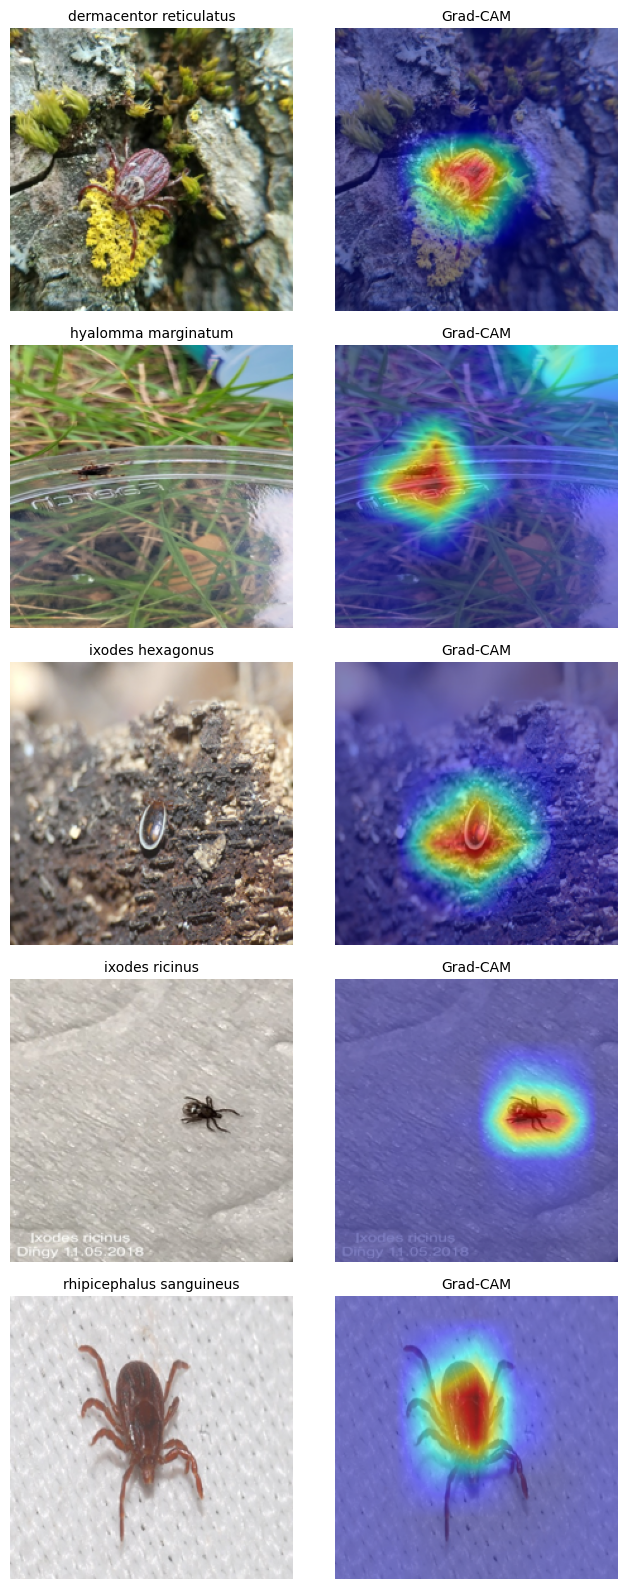

Saved -> figures/fig_gradcam_per_species.png


In [ ]:
# ============ PHASE 5: GRAD-CAM (RQ4) ============
!pip install -q grad-cam

import torch, torch.nn as nn, numpy as np, pandas as pd
from pathlib import Path
from PIL import Image
from torchvision import transforms, models
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

BASE = Path('/content/drive/MyDrive/tick_project')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

split_df = pd.read_csv(BASE/'dataset_split.csv')
CLASSES = sorted(split_df['folder'].unique())
CLASS_TO_IDX = {c:i for i,c in enumerate(CLASSES)}
IDX_TO_CLASS = {i:c for c,i in CLASS_TO_IDX.items()}

# --- Load trained EfficientNet-B0 ---
ckpt = torch.load(BASE/'model_efficientnet_b0.pt', map_location=device)
model = models.efficientnet_b0()
model.classifier[1] = nn.Linear(model.classifier[1].in_features, len(CLASSES))
model.load_state_dict(ckpt['model_state'])
model = model.to(device).eval()

# --- Grad-CAM target layer: last conv block of EfficientNet ---
target_layers = [model.features[-1]]

# --- Preprocessing (must match eval_tf exactly) ---
MEAN, STD = [0.485,0.456,0.406], [0.229,0.224,0.225]
eval_tf = transforms.Compose([
    transforms.Resize((224,224)), transforms.ToTensor(),
    transforms.Normalize(MEAN,STD)])

def load_for_cam(path):
    """Return (normalised tensor, rgb float image 0-1) for a given path."""
    img = Image.open(path).convert('RGB').resize((224,224))
    rgb = np.asarray(img, np.float32)/255.0          # for overlay
    tensor = eval_tf(img).unsqueeze(0).to(device)    # for the model
    return tensor, rgb

# --- Pick correctly-classified TEST images: one per species ---
test_rows = split_df[split_df['split']=='test'].reset_index(drop=True)
cam = GradCAM(model=model, target_layers=target_layers)

fig, axes = plt.subplots(len(CLASSES), 2, figsize=(7, 3.2*len(CLASSES)))

for row, cls in enumerate(CLASSES):
    # find a test image the model classifies correctly for this species
    cand = test_rows[test_rows['folder']==cls]
    chosen = None
    for _, r in cand.iterrows():
        path = BASE/'images'/r['folder']/r['filename']
        t, rgb = load_for_cam(path)
        with torch.no_grad():
            pred = model(t).argmax(1).item()
        if pred == CLASS_TO_IDX[cls]:
            chosen = (path, t, rgb); break
    if chosen is None:   # fall back to first image if none correct
        r = cand.iloc[0]; path = BASE/'images'/r['folder']/r['filename']
        t, rgb = load_for_cam(path); chosen = (path, t, rgb)

    path, t, rgb = chosen
    targets = [ClassifierOutputTarget(CLASS_TO_IDX[cls])]
    grayscale_cam = cam(input_tensor=t, targets=targets)[0]
    overlay = show_cam_on_image(rgb, grayscale_cam, use_rgb=True)

    axes[row,0].imshow(rgb);      axes[row,0].set_title(cls.replace('_',' '), fontsize=10)
    axes[row,0].axis('off')
    axes[row,1].imshow(overlay);  axes[row,1].set_title('Grad-CAM', fontsize=10)
    axes[row,1].axis('off')

plt.tight_layout()
(BASE/'figures').mkdir(exist_ok=True)
plt.savefig(BASE/'figures'/'fig_gradcam_per_species.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved -> figures/fig_gradcam_per_species.png")